In [2]:
!pip install roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 115.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.2 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="BeuKB1ot0eCALuNQFmf1")
project = rf.workspace("mohammed-o85f3").project("plant-health-tracker-9pb8w-wr9ke")
version = project.version(1)
dataset = version.download("yolov8-obb")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Plant-Health-Tracker-1 in yolov8-obb:: 100%|██████████| 4700/4700 [00:01<00:00, 4382.49it/s]


In [5]:
from google.colab import drive
drive.mount('/content/drive')
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    name="plant_health_model"
)

Mounted at /content/drive
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Plant-Health-Tracker-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ce85d95e5f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [6]:
metrics = model.val(
    data=f"{dataset.location}/data.yaml"
)

print(f"Precision:  {metrics.results_dict['metrics/precision(B)']:.4f}")
print(f"Recall:     {metrics.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP50:      {metrics.results_dict['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95:   {metrics.results_dict['metrics/mAP50-95(B)']:.4f}")

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2233.0±834.2 MB/s, size: 149.9 KB)
val: Scanning /content/Plant-Health-Tracker-1/valid/labels.cache... 310 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 310/310 76.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 2.1it/s 9.4s
                   all        310       4346      0.842      0.841      0.902       0.61
               healthy        309       1719      0.837      0.841      0.897      0.616
              stressed        305       2627      0.847      0.841      0.906      0.603
Speed: 3.7ms preprocess, 5.6ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to /content/runs/detect/val
Precision:  0.8419
Recall:     0.8409
mAP50:      0.9016
mAP50-95:   0.6095


In [7]:
model = YOLO('/content/runs/detect/plant_health_model/weights/best.pt')

test_images_path = f"{dataset.location}/test/images"

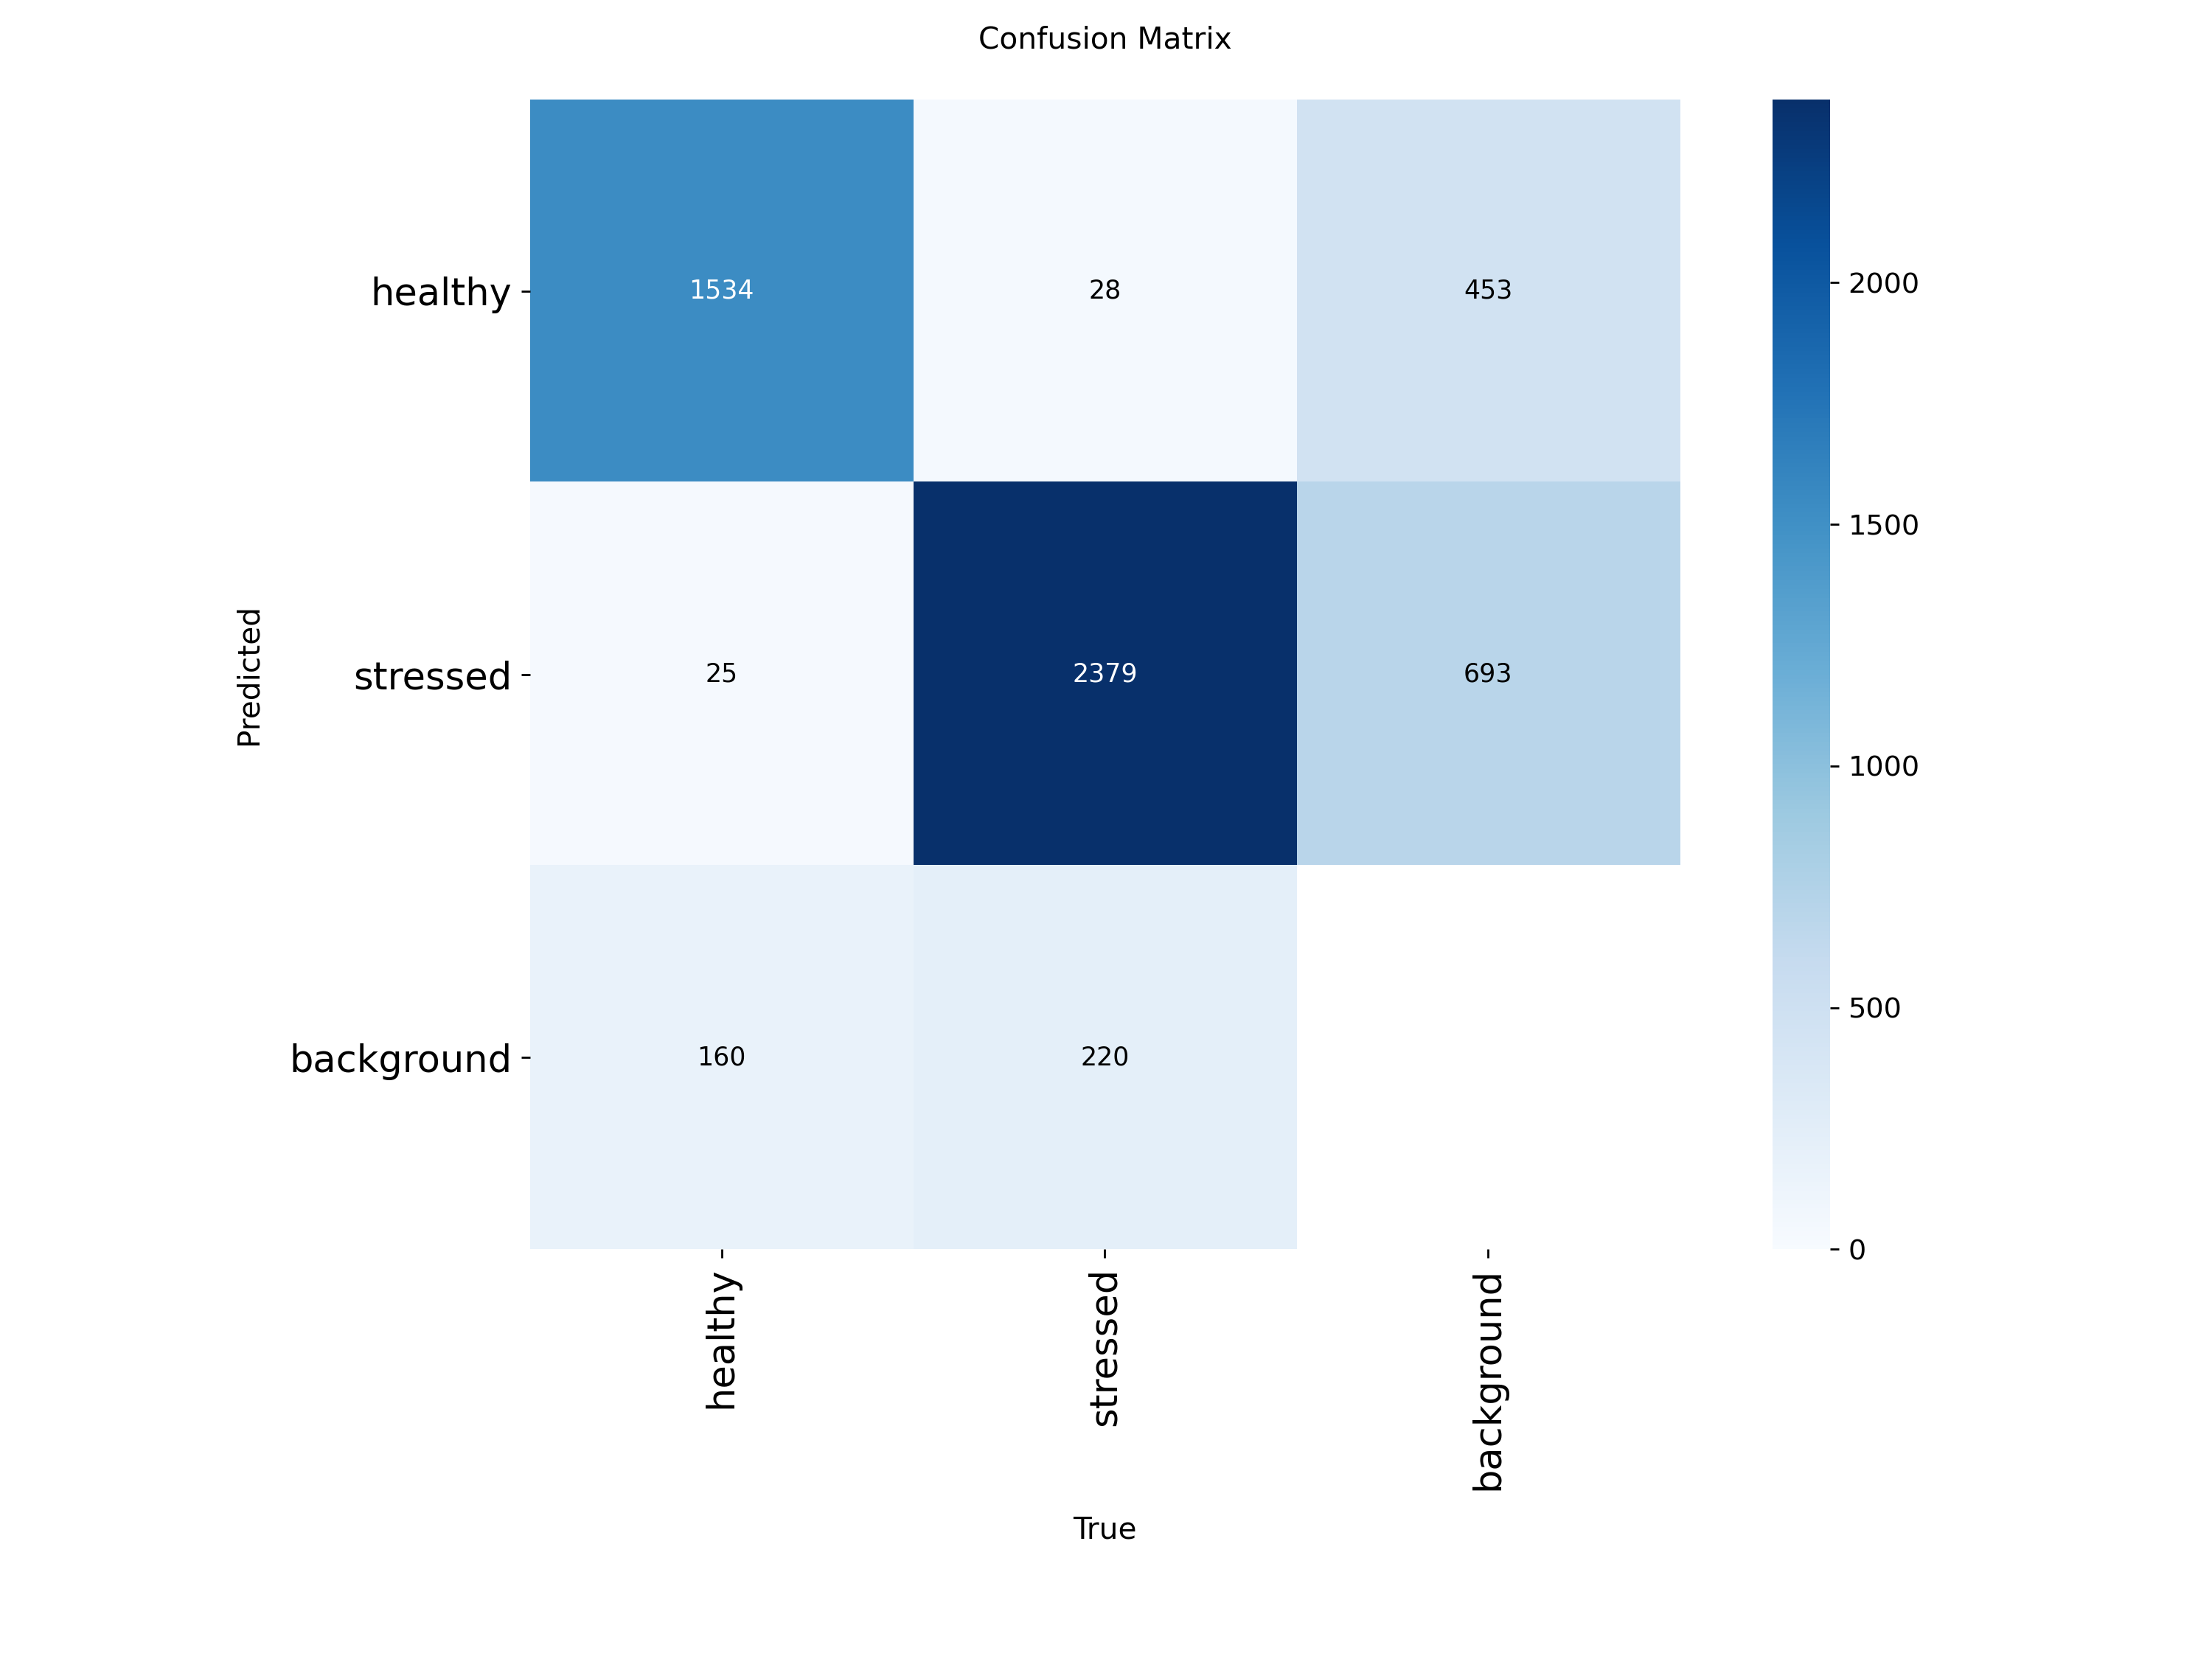

In [8]:
from IPython.display import Image, display

display(Image("/content/runs/detect/plant_health_model/confusion_matrix.png"))

In [9]:
import os

path = "/content/runs/detect/plant_health_model/weights/best.pt"

print(os.path.exists(path))

True


In [10]:
from google.colab import files

files.download("/content/runs/detect/plant_health_model/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>